In [1]:
from __Global__ import *

C:\ProgramData\miniforge3\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
class multiregression:
    def __init__(self):
        self.model_list = [
                           'composite_LAI_median']
    def run(self):
        # self.statistic_corr_boxplot()
        # self.statistic_contribution_no_residual()
        self.max_correlation_with_sign()

    def statistic_corr_boxplot(self):


        # === 1. read ===
        dff = result_root + rf'\Upload_Data\Figure4\partial_correlation\\1mm\\Obs.df'
        df = T.load_df(dff)
        df = self.df_clean(df)
        # print(len(df))



        # === 2. variable ===
        variable_list = [
            'sensitivity',
            'Precip_sum_detrend_CV',
            'CV_daily_rainfall_average',
        ]

        label_dic = {
            'sensitivity': r'$\gamma$',
            'Precip_sum_detrend_CV': r'$CV_{inter}$',
            'CV_daily_rainfall_average': r'$CV_{intra}$',
        }



        for model in self.model_list:


            result_dic = {}

            # print(len(df));exit()
            for variable in variable_list:
                new_variable = f'{model}_{variable}_sig'
                if new_variable not in df.columns:
                    continue

                vals = np.array(df[new_variable].tolist(), dtype=float)
                vals[(vals > 99) | (vals < -99)] = np.nan
                vals = vals[~np.isnan(vals)]
                # print(f'{variable}', len(vals))

                #     plt.hist(vals, bins=30)
                #     plt.axvline(np.mean(vals), color='g', label='Mean')
                #     plt.axvline(np.median(vals), color='r', label='Median')
                #     plt.legend()
                #     plt.show()

                # vals_mean=np.nanmean(vals)
                # print(vals_mean)
                result_dic[new_variable] = vals

            # === 5. organize data based on variable list order  ===
            data_list = []
            x_labels = []

            for var in variable_list:
                key = f'{model}_{var}_sig'
                if key in result_dic:
                    data_list.append(result_dic[key])
                    x_labels.append(label_dic[var])

                    # color
            color_list = ['#a577ad', 'yellowgreen', 'Pink', '#f599a1']
            dark_colors = ['#774685', 'Olive', 'Salmon', '#c3646f']  # 可以改为你自定义的 darken_color 函数

            # plot
            fig, ax = plt.subplots(figsize=(4, 3))

            box = ax.boxplot(
                data_list,
                patch_artist=True,
                widths=0.4,
                showfliers=False,

                showmeans=False,

            )

            # customize color

            for i, patch in enumerate(box['boxes']):
                face_color = color_list[i]
                edge_color = dark_colors[i]


                patch.set_facecolor(face_color)
                patch.set_edgecolor(edge_color)
                patch.set_linewidth(1.5)

                # median
                box['medians'][i].set_color(edge_color)
                box['medians'][i].set_linewidth(1.8)

                # （whisker）
                box['whiskers'][2 * i].set_color(edge_color)
                box['whiskers'][2 * i + 1].set_color(edge_color)
                box['whiskers'][2 * i].set_linewidth(1.2)
                box['whiskers'][2 * i + 1].set_linewidth(1.2)

                # （caps）
                box['caps'][2 * i].set_color(edge_color)
                box['caps'][2 * i + 1].set_color(edge_color)
                box['caps'][2 * i].set_linewidth(1.2)
                box['caps'][2 * i + 1].set_linewidth(1.2)

            #

            plt.xticks(range(1, len(x_labels) + 1), x_labels, fontsize=10)
            plt.xlabel('')
            plt.ylabel('Partial correlation', fontsize=10)

            plt.axhline(0, color='gray', linestyle='--')
            plt.tight_layout()
            plt.show()

            # outdir = result_root + rf'\FIGURE\SI\\'
            # Tools().mk_dir(outdir, force=True)
            # plt.show()

            # outf=join(outdir,f'{model}_partial_correlation_boxplot_3mm.pdf')
            # plt.savefig(outf,bbox_inches='tight',dpi=300
            #
            # )
            # plt.close()

    def  statistic_contribution_no_residual(self):
        import matplotlib.pyplot as plt
        import numpy as np
        import os

        dff = result_root + rf'\Upload_Data\Figure4\contribution\\1mm\\statistics.df'
        df = T.load_df(dff)
        df = self.df_clean(df)


        ## platte
        color_list = ['#a577ad', 'yellowgreen', 'Pink', '#f599a1']
        dark_colors = ['#774685', 'Olive', 'Salmon', '#c3646f']  # 可以改为你自定义的 darken_color 函数


        for model in self.model_list:
            if not 'median' in model:
                continue

            fixed_order = [
                f'{model}_sensitivity_zscore_trend_contrib',
                f'{model}_Precip_sum_detrend_CV_zscore_trend_contrib',
                f'{model}_CV_daily_rainfall_average_zscore_trend_contrib'

            ]

            label_map = {
                f'{model}_sensitivity_zscore_trend_contrib': 'γ',
                f'{model}_Precip_sum_detrend_CV_zscore_trend_contrib': 'CV_inter',
                f'{model}_CV_daily_rainfall_average_zscore_trend_contrib':'CV_intra'

            }

            means, sems, labels = [], [], []
            print(len(df))

            df = df[df[f'{model}_detrend_CV_zscore_trend'] > 0]
            df = df[df[f'{model}_detrend_CV_zscore_p_value'] < 0.05]
            #
            # print(len(df));exit()

            ## calculate mean and sem
            for var in fixed_order:
                if var not in df.columns:
                    continue
                vals = np.array(df[var].values, dtype=float)
                vals[(vals > 99) | (vals < -99)] = np.nan
                vals = vals[~np.isnan(vals)]
                # print(vals);exit()
                if len(vals) == 0:
                    continue

                mean_val = np.nanmean(vals)
                # print(np.std(vals));exit()
                sem_val = np.nanstd(vals) / np.sqrt(len(vals))  # 标准误差

                means.append(mean_val)
                sems.append(sem_val)
                labels.append(label_map[var])
            # print(sems)
            # print(means);exit()
            # print(f'{model}:', means)

          ## plot
            fig, ax = plt.subplots(figsize=(4, 3))
            x = np.arange(len(labels))
            colors = color_list
            edges = dark_colors

            bars = ax.bar(
                x, means, width=0.4,
                color=colors, edgecolor=edges, linewidth=1.2, zorder=2
            )


            for xi, mean, sem, edge in zip(x, means, sems, edges):
                ax.errorbar(
                    xi, mean, yerr=sem,
                    fmt='none', ecolor=edge, elinewidth=1.2, capsize=4, zorder=3
                )


            ax.axhline(0, color='gray', linestyle='--', lw=1)
            ax.set_xticks(x)
            ax.set_xticklabels(labels, fontsize=12)
            ax.set_ylabel('Attribution of CVLAI (%)', fontsize=12)
            ax.set_yticklabels(ax.get_yticks(), fontsize=12)
            # ax.spines['top'].set_visible(False)
            # ax.spines['right'].set_visible(False)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['bottom'].set_linewidth(1)
            ax.tick_params(axis='y', width=1, length=3)
            ax.tick_params(axis='x', width=1, length=0)
            # plt.tight_layout()

            plt.show()



    def df_clean(self, df):
        # T.print_head_n(df)
        # df = df.dropna(subset=[self.y_variable])
        # T.print_head_n(df)
        # exit()
        df = df[df['row'] > 60]
        df = df[df['Aridity'] < 0.65]
        df = df[df['LC_max'] < 10]
        df = df[df['MODIS_LUCC'] != 12]

        df = df[df['landcover_classfication'] != 'Cropland']

        return df

    def max_correlation_with_sign(self):

        dff = result_root + rf'\\Upload_Data\Figure4\Obs_TRENDY_comparison\\Obs_TRENDY_comparison.df'
        df = T.load_df(dff)
        df = self.df_clean(df)
        df = df[df['composite_LAI_median_detrend_CV_zscore_trend'] > 0]
        df = df[df['composite_LAI_median_detrend_CV_zscore_p_value'] < 0.05]

        model_list = ['composite_LAI_median', 'TRENDY_ensemble_median_2']

        var_list = [
            'sensitivity',
            'Precip_sum_detrend_CV',
            'CV_daily_rainfall_average',
        ]

        for model in tqdm(model_list):
            # if not 'TRENDY_ensemble_mean2' in model:
            #     continue

            outdir = result_root + rf'\partial_correlation\TRENDY\result\\{model}\\'
            T.mk_dir(outdir, force=True)

            # === merge variable name with model name ===
            var_list_sens = [f'{model}_' + v for v in var_list]

            max_var_list = []
            color_list = []
            trend_val_list = []

            for _, row in df.iterrows():
                # ======
                vals_sens = np.array([row[v] for v in var_list_sens], dtype=float)
                vals_sens[(vals_sens < -10) | (vals_sens > 10)] = np.nan

                if np.all(np.isnan(vals_sens)):
                    max_var_list.append(np.nan)
                    color_list.append(np.nan)
                    trend_val_list.append(np.nan)
                    continue

                # === find max value abs ===
                idx_max = np.nanargmax(np.abs(vals_sens))
                max_var = var_list[idx_max]  # 注意取原始名字 (e.g. 'sensitivity')

                # === 嵌套逻辑：dominant + trend方向 ===
                if 'sensitivity' in max_var:
                    color = 1
                elif 'Precip_sum_detrend_CV' in max_var:

                    color = 2

                elif 'CV_daily_rainfall_average' in max_var:

                    color = 3

                else:
                    color = np.nan

                max_var_list.append(max_var)
                color_list.append(color)

            df['max_var'] = max_var_list
            df['color'] = color_list

            # ===  color_map ===
            outdir = outdir
            spatial_dic = T.df_to_spatial_dic(df, 'color')
            # out_tif = join(outdir, 'dominant_color_map_without_sign.tif')
            # DIC_and_TIF().pix_dic_to_tif(spatial_dic, out_tif)

            arr = DIC_and_TIF().pix_dic_to_spatial_arr(spatial_dic)
            from matplotlib.colors import ListedColormap, BoundaryNorm

            # === 定义离散颜色 ===
            cmap = ListedColormap([
                '#1f78b4',  # 1: rainfall sensitivity (γ)
                '#33a02c',  # 2: CV_inter rainfall
                '#e31a1c'  # 3: CV_intra rainfall
            ])

            # === boundaries===
            bounds = [0.5, 1.5, 2.5, 3.5]
            norm = BoundaryNorm(bounds, cmap.N)


            plt.imshow(arr, interpolation='nearest', cmap=cmap, norm=norm)

            cbar = plt.colorbar(ticks=[1, 2, 3])
            cbar.ax.set_yticklabels([
                'Rainfall sensitivity (γ)',
                'CV_inter rainfall',
                'CV_intra rainfall'
            ])

            plt.title(f'{model} - Dominant factor for LAI variability')
            plt.show()



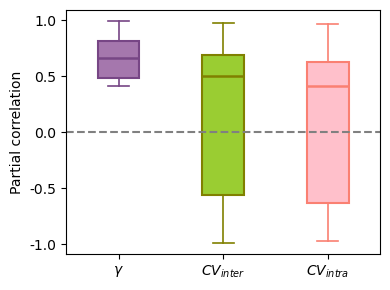

In [3]:
multiregression().statistic_corr_boxplot()

9766


C:\Users\wenzhang1.BLUECAT\AppData\Local\Temp\ipykernel_103860\1321123125.py:222: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=12)


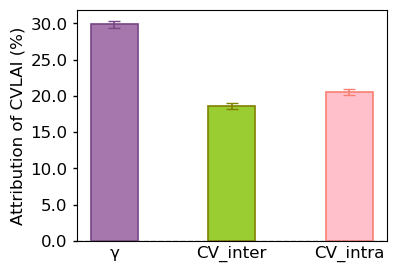

In [4]:
multiregression().statistic_contribution_no_residual()

  0%|                                                                                            | 0/2 [00:00<?, ?it/s]C:\Users\wenzhang1.BLUECAT\AppData\Local\Temp\ipykernel_103860\1321123125.py:311: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['max_var'] = max_var_list
C:\Users\wenzhang1.BLUECAT\AppData\Local\Temp\ipykernel_103860\1321123125.py:312: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['color'] = color_list


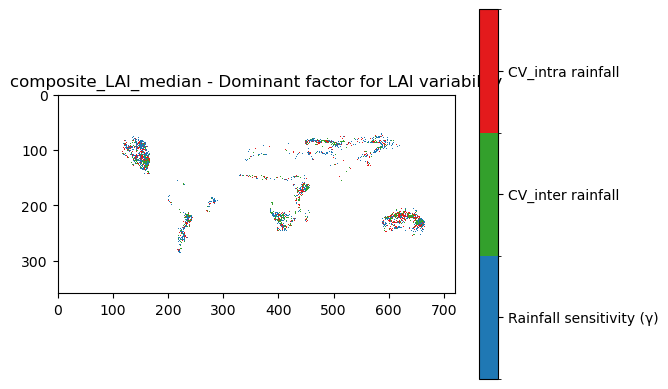

 50%|██████████████████████████████████████████                                          | 1/2 [00:00<00:00,  1.87it/s]

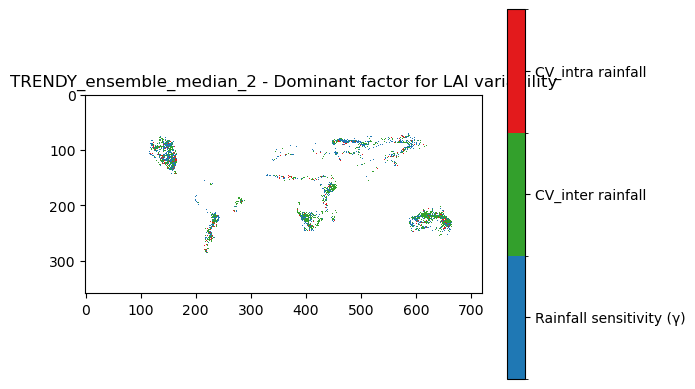

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.86it/s]


In [5]:
multiregression().max_correlation_with_sign()